Shape: (1010, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Loan_ID          1010 non-null   object 
 1   Age              1010 non-null   int64  
 2   Gender           1010 non-null   object 
 3   Annual_Income    1010 non-null   int64  
 4   Employment_Type  1010 non-null   object 
 5   Credit_Score     1010 non-null   int64  
 6   Loan_Amount      1010 non-null   int64  
 7   Interest_Rate    1010 non-null   float64
 8   Loan_Term        1010 non-null   int64  
 9   Existing_Debt    1010 non-null   int64  
 10  Loan_Purpose     1010 non-null   object 
 11  Education        1010 non-null   object 
 12  Marital_Status   1010 non-null   object 
 13  Property_Area    1010 non-null   object 
 14  Default          1010 non-null   int64  
dtypes: float64(1), int64(7), object(7)
memory usage: 118.5+ KB
None
  Loan_ID  Age  Gender  

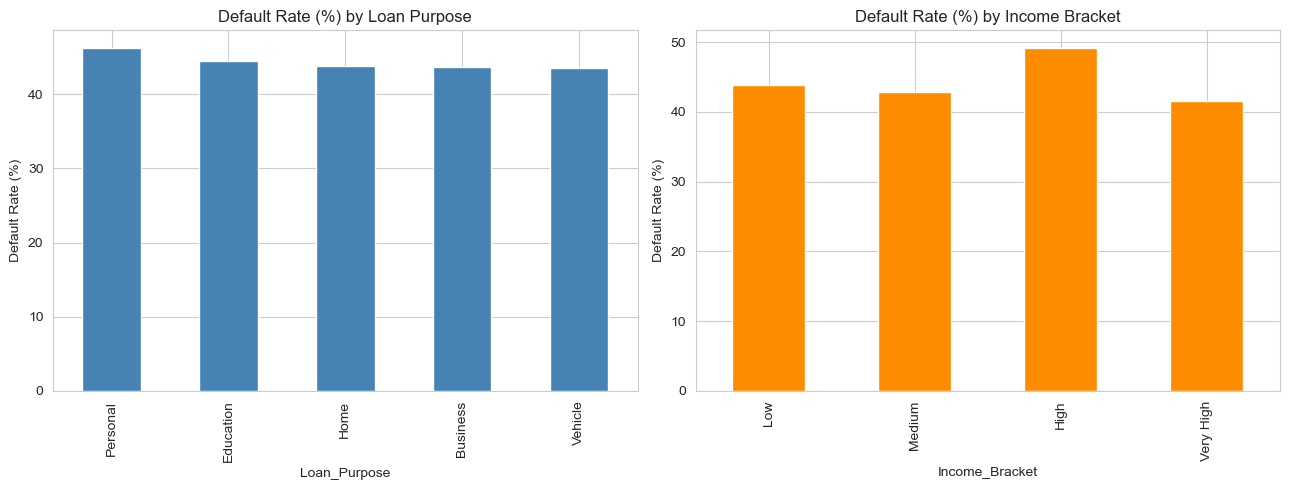


--- Chi-Square Test: Income Bracket vs Default ---
Contingency Table:
 Default           0    1
Income_Bracket          
Low             142  111
Medium          144  108
High            128  124
Very High       148  105
Chi2 Statistic : 3.4902
Degrees of Freedom: 3
P-value        : 0.3220
Result: p >= 0.05 -> Fail to reject H0. No significant effect of income bracket on default.

--- Model Comparison ---
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.594059   0.555556 0.444444  0.493827 0.581944
      Random Forest  0.608911   0.577465 0.455556  0.509317 0.611310

Classification Report - Logistic Regression:
               precision    recall  f1-score   support

           0       0.62      0.71      0.66       112
           1       0.56      0.44      0.49        90

    accuracy                           0.59       202
   macro avg       0.59      0.58      0.58       202
weighted avg       0.59      0.59      0.59       202


Classifi

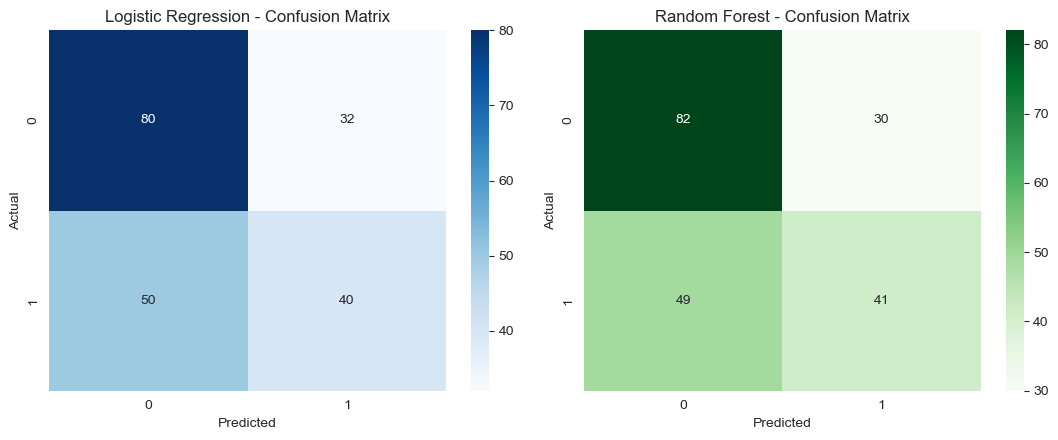

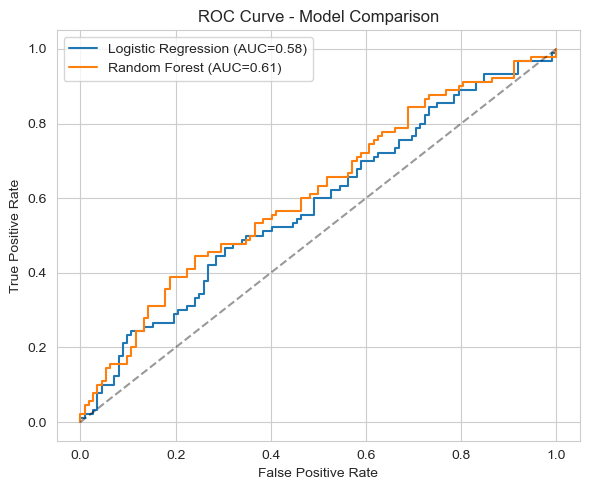


Random Forest - Feature Importance:
 Interest_Rate      0.151576
Credit_Score       0.145861
Existing_Debt      0.133600
Loan_Amount        0.124541
Annual_Income      0.114840
Age                0.104605
Loan_Term          0.044478
Loan_Purpose       0.044421
Employment_Type    0.034556
Education          0.033151
Property_Area      0.028269
Gender             0.023742
Marital_Status     0.016360
dtype: float64


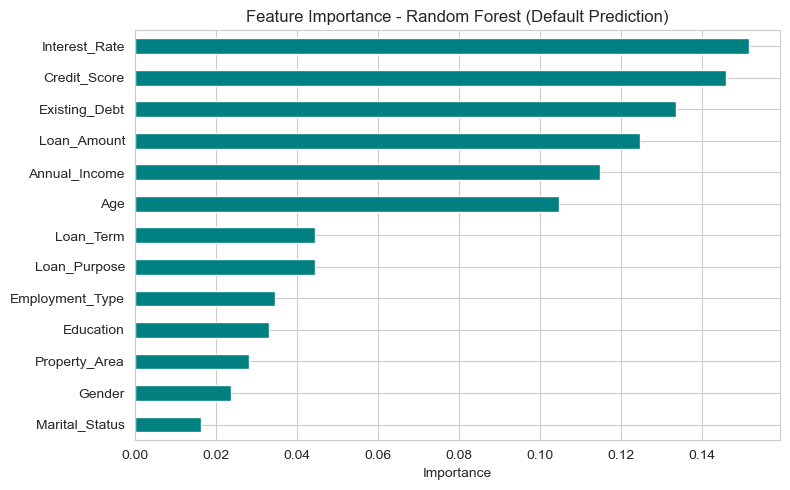


All outputs saved: default_rate_summary.png, confusion_matrices.png, roc_curve_comparison.png, feature_importance.png, model_comparison_results.csv


In [4]:
"""
Bank Loan Default & Credit Risk Analysis
==========================================
Covers:
  1. Data loading & cleaning
  2. Descriptive statistics
  3. Pivot summary (default rate by loan type / income bracket)
  4. Hypothesis test - Chi-square (Does income bracket significantly affect default rate?)
  5. Logistic Regression for default prediction
  6. Random Forest for default prediction
  7. Model comparison (Accuracy, Precision, Recall, F1, ROC-AUC)

Dataset columns: Loan_ID, Age, Gender, Annual_Income, Employment_Type, Credit_Score,
Loan_Amount, Interest_Rate, Loan_Term, Existing_Debt, Loan_Purpose, Education,
Marital_Status, Property_Area, Default
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

sns.set_style("whitegrid")

# -------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------
FILE_PATH = "Bank_Loan_Dataset 2.csv"   # change path if needed
df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
print(df.info())
print(df.head())

# -------------------------------------------------------------------
# 2. DATA CLEANING
# -------------------------------------------------------------------
# Drop exact duplicates
df = df.drop_duplicates()

# Check & handle missing values (if any)
print("\nMissing values:\n", df.isnull().sum())
df = df.dropna()  # dataset is clean, but kept as safeguard

# Strip whitespace from string/categorical columns
cat_cols = df.select_dtypes(include="object").columns.tolist()
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()

# Basic sanity filters (remove impossible values, if any exist)
df = df[(df["Age"] > 0) & (df["Annual_Income"] > 0) & (df["Loan_Amount"] > 0)]

# -------------------------------------------------------------------
# 3. FEATURE ENGINEERING - Income Bracket (for pivot + hypothesis test)
# -------------------------------------------------------------------
df["Income_Bracket"] = pd.qcut(
    df["Annual_Income"], q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

# -------------------------------------------------------------------
# 4. DESCRIPTIVE STATISTICS
# -------------------------------------------------------------------
print("\nDescriptive statistics (numeric columns):")
print(df.describe())

print("\nOverall default rate: {:.2f}%".format(df["Default"].mean() * 100))

# -------------------------------------------------------------------
# 5. PIVOT SUMMARY - Default rate by Loan Purpose & Income Bracket
# -------------------------------------------------------------------
pivot_loan_purpose = pd.pivot_table(
    df, values="Default", index="Loan_Purpose", aggfunc="mean"
).sort_values("Default", ascending=False) * 100

pivot_income_bracket = pd.pivot_table(
    df, values="Default", index="Income_Bracket", aggfunc="mean", observed=True
) * 100

print("\nDefault Rate (%) by Loan Purpose:\n", pivot_loan_purpose)
print("\nDefault Rate (%) by Income Bracket:\n", pivot_income_bracket)

# Simple visualizations
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pivot_loan_purpose["Default"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Default Rate (%) by Loan Purpose")
axes[0].set_ylabel("Default Rate (%)")

pivot_income_bracket["Default"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Default Rate (%) by Income Bracket")
axes[1].set_ylabel("Default Rate (%)")
plt.tight_layout()
plt.savefig("default_rate_summary.png", dpi=150)
plt.show()

# -------------------------------------------------------------------
# 6. HYPOTHESIS TEST - Chi-Square
#    H0: Income bracket has NO effect on default rate (independent)
#    H1: Income bracket significantly affects default rate
# -------------------------------------------------------------------
contingency = pd.crosstab(df["Income_Bracket"], df["Default"])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("\n--- Chi-Square Test: Income Bracket vs Default ---")
print("Contingency Table:\n", contingency)
print(f"Chi2 Statistic : {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value        : {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"Result: p < {alpha} -> Reject H0. Income bracket SIGNIFICANTLY affects default rate.")
else:
    print(f"Result: p >= {alpha} -> Fail to reject H0. No significant effect of income bracket on default.")

# -------------------------------------------------------------------
# 7. PREPARE DATA FOR MACHINE LEARNING
# -------------------------------------------------------------------
model_df = df.drop(columns=["Loan_ID", "Income_Bracket"])  # drop ID and derived bracket

# Encode categorical variables
le_dict = {}
for col in model_df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    le_dict[col] = le

X = model_df.drop(columns=["Default"])
y = model_df["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (mainly benefits Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------------------------------------------
# 8. LOGISTIC REGRESSION
# -------------------------------------------------------------------
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# -------------------------------------------------------------------
# 9. RANDOM FOREST
# -------------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, random_state=42, class_weight="balanced"
)
rf.fit(X_train, y_train)  # tree models don't need scaling

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# -------------------------------------------------------------------
# 10. MODEL EVALUATION & COMPARISON
# -------------------------------------------------------------------
def evaluate(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
    }

results = pd.DataFrame([
    evaluate("Logistic Regression", y_test, y_pred_lr, y_prob_lr),
    evaluate("Random Forest", y_test, y_pred_rf, y_prob_rf),
])

print("\n--- Model Comparison ---")
print(results.to_string(index=False))

print("\nClassification Report - Logistic Regression:\n",
      classification_report(y_test, y_pred_lr))
print("\nClassification Report - Random Forest:\n",
      classification_report(y_test, y_pred_rf))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d",
            cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression - Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d",
            cmap="Greens", ax=axes[1])
axes[1].set_title("Random Forest - Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

# ROC Curve comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_comparison.png", dpi=150)
plt.show()

# -------------------------------------------------------------------
# 11. FEATURE IMPORTANCE (Random Forest)
# -------------------------------------------------------------------
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nRandom Forest - Feature Importance:\n", importance)

plt.figure(figsize=(8, 5))
importance.plot(kind="barh", color="teal")
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest (Default Prediction)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

# -------------------------------------------------------------------
# 12. SAVE FINAL RESULTS
# -------------------------------------------------------------------
results.to_csv("model_comparison_results.csv", index=False)
print("\nAll outputs saved: default_rate_summary.png, confusion_matrices.png, "
      "roc_curve_comparison.png, feature_importance.png, model_comparison_results.csv")